最大値 1 の確率: 0.037
最大値 2 の確率: 0.094
最大値 3 の確率: 0.115
最大値 4 の確率: 0.218
最大値 5 の確率: 0.247
最大値 6 の確率: 0.289


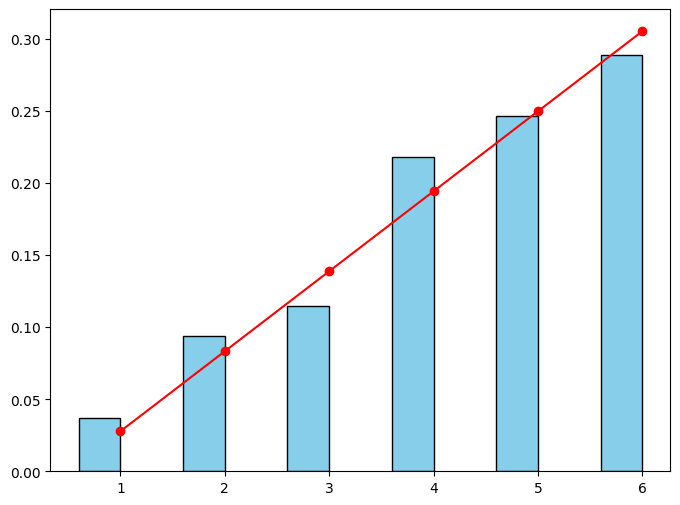

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ

n_rolls = 1000 # シュミレーションの回数

# サイコロを２個振る

die1 = np.random.randint(1,7, size = n_rolls)
die2 = np.random.randint(1,7, size = n_rolls)

# 最大値を求める
max_values = np.maximum(die1, die2)

# 度数を数える
counts = np.bincount(max_values)[1:]

# 確率に変換
probs = counts/n_rolls


# 理論値
theory = []

for k in range(1,7):
    upper = (k/6)**2
    lower = ((k-1)/6)**2
    theory.append(upper - lower)



# グラフを描く

x = np.arange(1, 7)
for value, prob in enumerate(probs, start=1):
    print(f"最大値 {value} の確率: {prob:.3f}")

plt.figure(figsize=(8, 6))
plt.bar(x-0.2, probs, width=0.4, color='skyblue', edgecolor='black')
plt.plot(x, theory, color='red', marker='o', linestyle='-', label='理論値')

最大値 1 の確率: 0.008
最大値 2 の確率: 0.033
最大値 3 の確率: 0.091
最大値 4 の確率: 0.166
最大値 5 の確率: 0.270
最大値 6 の確率: 0.432


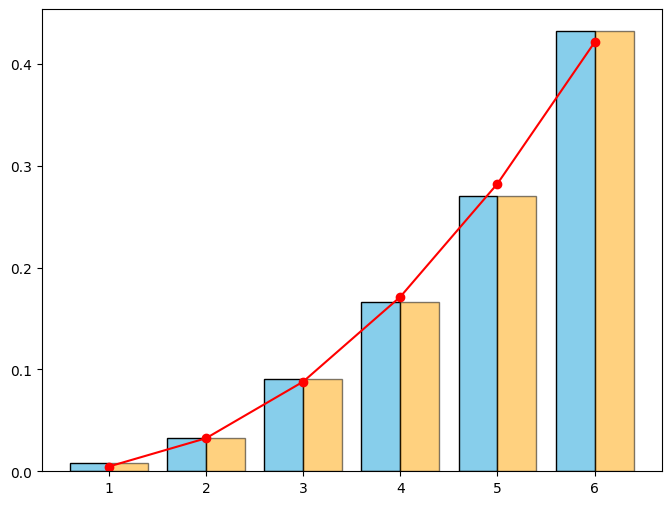

In [14]:
# パラメータ

n_rolls = 1000 # シュミレーションの回数

# サイコロを3個振る

die1 = np.random.randint(1,7, size = n_rolls)
die2 = np.random.randint(1,7, size = n_rolls)
die3 = np.random.randint(1,7, size = n_rolls)

# 最大値を求める
max_values = np.maximum.reduce([die1, die2, die3])

# 度数を数える
counts = np.bincount(max_values)[1:]
max_pmf = np.zeros(6)

for i in range(1,7):
    max_pmf[i-1] = np.sum(max_values == i)/n_rolls

# 確率に変換
probs = counts/n_rolls


# 理論値
theory = []

for k in range(1,7):
    upper = (k/6)**3
    lower = ((k-1)/6)**3
    theory.append(upper - lower)



# グラフを描く

x = np.arange(1, 7)
for value, prob in enumerate(probs, start=1):
    print(f"最大値 {value} の確率: {prob:.3f}")

plt.figure(figsize=(8, 6))
plt.bar(x-0.2, probs, width=0.4, color='skyblue', edgecolor='black')
plt.bar(x+0.2, max_pmf, width=0.4,color='orange', edgecolor='black', alpha=0.5, label='3個のサイコロの最大値の確率分布')
plt.plot(x, theory, color='red', marker='o', linestyle='-', label='理論値')

In [15]:
# 3個の6面サイコロの和の分布

# 1個のサイコロのPMF
dice = np.ones(6)/6

# 畳み込みを３回
sum_pmf = dice

for _ in range(2):
    sum_pmf = np.convolve(sum_pmf, dice)


# Key (和の値)
sums = np.arange(3,19)

print("3個のサイコロの和の分布")
for s,p in zip(sums, sum_pmf):
    print(f"和 {s} の確率: {p:.3f}")


3個のサイコロの和の分布
和 3 の確率: 0.005
和 4 の確率: 0.014
和 5 の確率: 0.028
和 6 の確率: 0.046
和 7 の確率: 0.069
和 8 の確率: 0.097
和 9 の確率: 0.116
和 10 の確率: 0.125
和 11 の確率: 0.125
和 12 の確率: 0.116
和 13 の確率: 0.097
和 14 の確率: 0.069
和 15 の確率: 0.046
和 16 の確率: 0.028
和 17 の確率: 0.014
和 18 の確率: 0.005


In [18]:
# 最大値の分布

n = 6 # 最大値をとる回数

# 累積分布 F(s)
cdf = np.cumsum(sum_pmf)

# 最大値の累積分布 F_max(s) = F(s)^n
max_cdf = cdf**n

# 差分をとってPMFへ戻す
max_pmf = np.diff(np.insert(max_cdf,0,0))

for s,p in zip(sums, max_pmf):
    print(f"最大値 {s} の確率: {p:.3f}")

print("\n６回振った最大値の分布")
print(max_pmf.sum())

最大値 3 の確率: 0.000
最大値 4 の確率: 0.000
最大値 5 の確率: 0.000
最大値 6 の確率: 0.000
最大値 7 の確率: 0.000
最大値 8 の確率: 0.000
最大値 9 の確率: 0.002
最大値 10 の確率: 0.013
最大値 11 の確率: 0.044
最大値 12 の確率: 0.106
最大値 13 の確率: 0.181
最大値 14 の確率: 0.212
最大値 15 の確率: 0.194
最大値 16 の確率: 0.141
最大値 17 の確率: 0.079
最大値 18 の確率: 0.027

６回振った最大値の分布
0.9999999999999993
